In [4]:
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [5]:
df = pd.read_csv('C:\\Users\\themo\\OneDrive\\Desktop\\Machine Learning\\Project\\monthly_average_BATS_cleaned.csv')
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


In [6]:
df_clustering = df.drop(['year_month'], axis=1)
df_clustering.head()

,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
0,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
2,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
3,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
4,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


In [7]:
df_clustering.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   depth               378 non-null    float64
 1   Temperature         378 non-null    float64
 2   Salinity            378 non-null    float64
 3   Oxygen_1            378 non-null    float64
 4   CO2                 378 non-null    float64
 5   Alkalinity          378 non-null    float64
 6   NO3_plus_NO2        378 non-null    float64
 7   NO2                 378 non-null    float64
 8   PO4                 378 non-null    float64
 9   Silicate            378 non-null    float64
 10  POC                 378 non-null    float64
 11  PON                 378 non-null    float64
 12  TOC                 378 non-null    float64
 13  Bact_Enum           378 non-null    float64
 14  year                378 non-null    int64  
 15  CO2_rolling         367 non-null    float64
 16  Alkalini

In [8]:
# Option 1: Drop rows with any NaNs (safe for clustering)
df_clustering = df_clustering.dropna()
# Option 2: Fill NaNs with column mean (alternative)
# df_clustering = df_clustering.fillna(df_clustering.mean())
df_clustering.head()

,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
11,798.038333,15.080417,35.735333,222.940000,2057.400000,2393.725000,11.961389,0.000000,0.769167,10.861944,11.819474,1.791579,54.4,2.594444,1992,2061.219697,2390.648801
12,600.995122,16.154793,35.962778,220.812766,2054.833333,2393.133333,9.537083,0.001083,0.580851,8.523958,11.950938,2.243438,54.4,3.026667,1993,2061.100947,2390.221275
13,425.449206,17.153960,35.952063,222.934783,2061.108333,2393.747826,8.415217,0.018468,0.556596,8.393333,15.704828,3.494483,54.4,3.944828,1993,2061.054419,2391.536372
14,390.710490,17.125671,35.992152,224.334783,2069.420833,2393.287500,8.522766,0.023447,0.507609,7.448043,18.166452,3.717742,54.4,3.633333,1993,2061.626989,2391.635330
15,440.690598,17.266308,36.011043,224.682222,2063.825000,2392.891667,7.897778,0.009978,0.521556,8.501702,16.249063,3.223438,54.4,4.500000,1993,2061.095044,2391.524219


In [9]:
from sklearn.preprocessing import StandardScaler

# Scale the features before clustering
scaler = StandardScaler()
df_clustering_scaled = scaler.fit_transform(df_clustering)
# df_clustering_scaled is a numpy array; use this for KMeans

In [10]:
inertia_score = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_clustering_scaled)
    inertia_score.append(kmeans.inertia_)

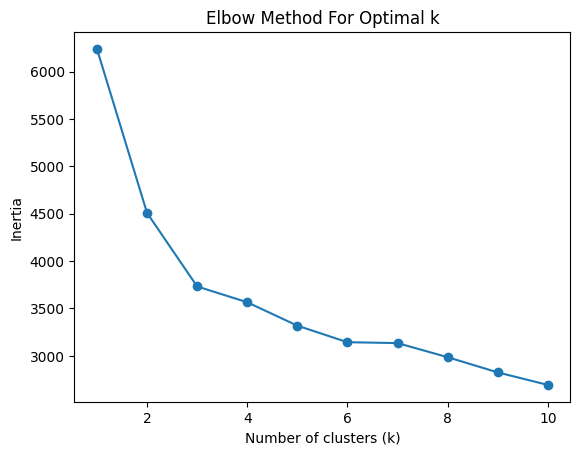

In [11]:
# Plot the inertia scores to use the elbow method
plt.plot(range(1, 11), inertia_score, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.savefig('inertia_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

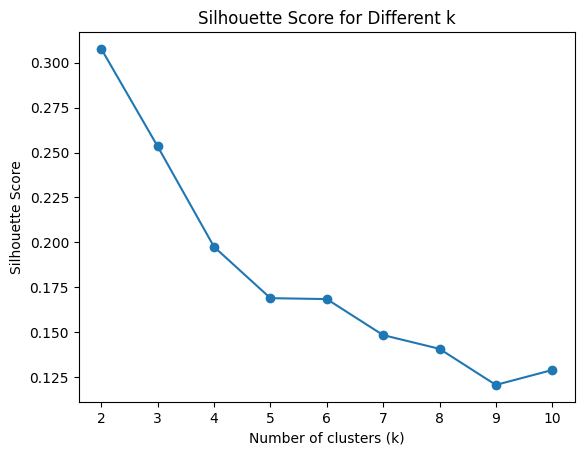

Best k by silhouette score: 2


In [12]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for k from 2 to 10
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df_clustering_scaled)
    score = silhouette_score(df_clustering_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the best k based on silhouette score
best_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}')

k=2: Inertia=4508.01, Silhouette Score=0.308
k=3: Inertia=3732.43, Silhouette Score=0.253


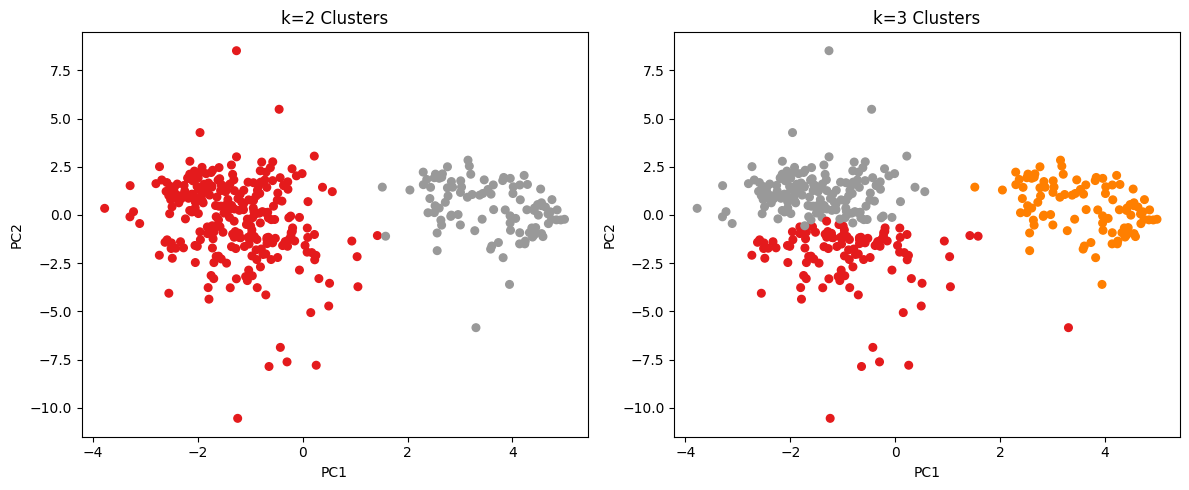

In [13]:
# Compare clustering results for k=2 and k=3
k_values = [2, 3]
results = {}
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df_clustering_scaled)
    inertia = kmeans.inertia_
    sil_score = silhouette_score(df_clustering_scaled, labels)
    results[k] = {'labels': labels, 'inertia': inertia, 'silhouette': sil_score}
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette Score={sil_score:.3f}")

# Optionally, visualize the clusters (for first two principal components)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_clustering_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, k in enumerate(k_values):
    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=results[k]['labels'], cmap='Set1', s=30)
    axes[idx].set_title(f'k={k} Clusters')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
plt.tight_layout()
plt.savefig('k2_vs_k3_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

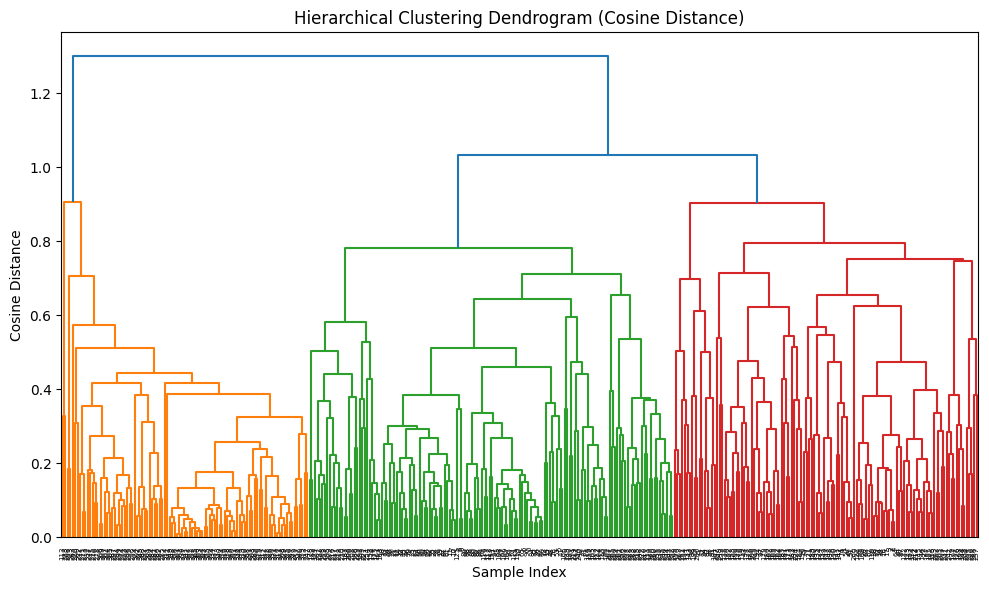

Cluster labels for k=3: [2 3 3 3 3 2 2 2 2 2 2 2 2 2 3 2 3 3 2 2 2 2 2 2 2 2 3 3 3 2 2 2 2 2 2 2 2
 2 3 3 3 2 2 3 2 2 2 2 2 3 3 3 2 2 2 2 2 2 2 2 2 2 3 3 3 2 2 2 2 2 2 3 3 3
 3 3 2 3 2 2 2 2 2 2 2 2 2 3 2 2 2 3 3 3 3 2 2 3 3 3 3 3 2 2 2 2 2 2 2 3 3
 2 2 1 2 2 2 2 2 2 2 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 2 3 3 3 3 3 3 2 2 3 2 3 2 3 3 2 3 3 3 3 3 3 3 2 2 3 2 2 3 3 3 2 3 3
 3 2 2 2 3 2 2 3 2 2 2 3 3 2 3 3 3 3 3 3 2 2 2 2 2 2 2 3 3 3 2 2 2 2 2 2 2
 2 2 3 3 3 2 2 2 2 2 2 1 3 2 3 3 3 2 2 3 3 2 2 2 2 3 2 3 2 3 2 2 2 2 2 3 2
 3 3 2 2 3 2 2 2 2 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Compute the cosine distance matrix
cosine_dist = pdist(df_clustering_scaled, metric='cosine')

# Perform hierarchical clustering using the linkage method (e.g., 'average')
Z = linkage(cosine_dist, method='average')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Cosine Distance)')
plt.xlabel('Sample Index')
plt.ylabel('Cosine Distance')
plt.tight_layout()
plt.savefig('hierarchical_dendrogram_cosine.png', dpi=150, bbox_inches='tight')
plt.show()

# Example: Assign clusters for a chosen number of clusters (e.g., k=3)
hier_labels = fcluster(Z, 3, criterion='maxclust')
print('Cluster labels for k=3:', hier_labels)

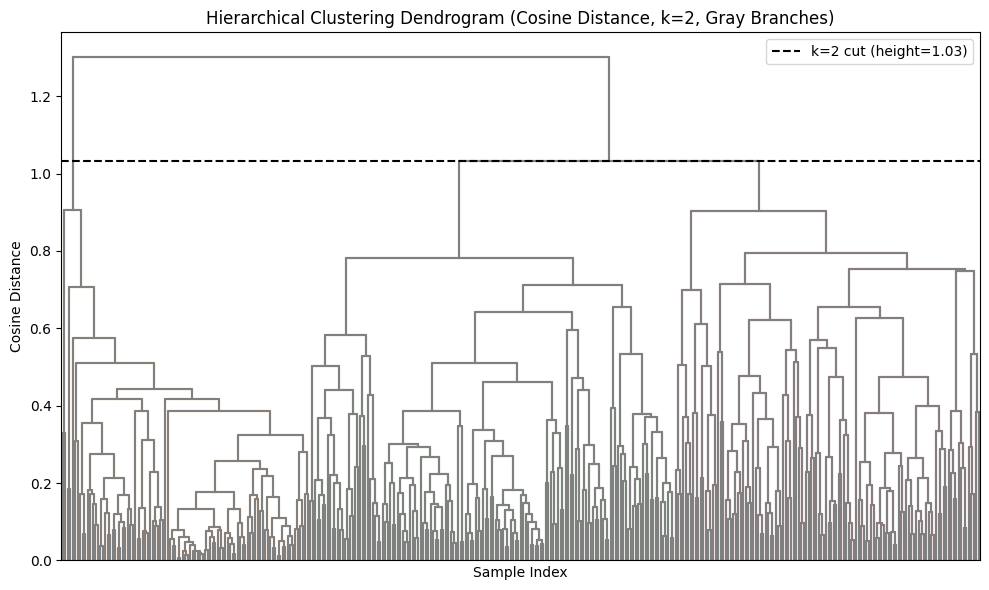

In [19]:
# Dendrogram with all branches gray and leaves colored by k=2 cluster assignment
labels_k2 = fcluster(Z, 2, criterion='maxclust')
leaf_colors = np.array(['tab:blue', 'tab:orange'])[labels_k2 - 1]

fig, ax = plt.subplots(figsize=(10, 6))
ddata = dendrogram(Z, color_threshold=None, above_threshold_color='gray', ax=ax, no_labels=True)
# Set all branches to gray
for icoord, dcoord in zip(ddata['icoord'], ddata['dcoord']):
    ax.plot(icoord, dcoord, color='gray')
# Color the leaves
for tick, color in zip(ax.get_xticks(), leaf_colors[ddata['leaves']]):
    ax.plot([tick], [0], marker='o', color=color, markersize=8)
plt.axhline(y=Z[-2, 2], c='k', ls='--', label=f'k=2 cut (height={Z[-2,2]:.2f})')
plt.title('Hierarchical Clustering Dendrogram (Cosine Distance, k=2, Gray Branches)')
plt.xlabel('Sample Index')
plt.ylabel('Cosine Distance')
plt.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram_k2_gray_branches.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Output the head of the original and cleaned/scaled dataframes as HTML for website inclusion
# Original data head
original_html = df.head().to_html(index=False)
with open('original_data_head.html', 'w', encoding='utf-8') as f:
    f.write(original_html)

# Cleaned and scaled data head (convert scaled array back to DataFrame for display)
if isinstance(df_clustering_scaled, np.ndarray):
    scaled_head = pd.DataFrame(df_clustering_scaled, columns=df_clustering.columns, index=df_clustering.index).head()
else:
    scaled_head = df_clustering_scaled.head()
scaled_html = scaled_head.to_html(index=False)
with open('cleaned_scaled_data_head.html', 'w', encoding='utf-8') as f:
    f.write(scaled_html)

# Display HTML in notebook for preview
from IPython.display import display, HTML
display(HTML('<h3>Original Data Head</h3>' + original_html))
display(HTML('<h3>Cleaned & Scaled Data Head</h3>' + scaled_html))

year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
2.363954,-2.062336,-0.648830,0.402820,-1.301238,0.705674,0.976389,-0.727995,0.950600,0.734709,-0.954000,-1.083280,0.890476,-0.340071,-1.739978,-1.179202,0.542878
1.015218,-1.358476,0.536558,-0.088737,-1.388716,0.667951,0.046280,-0.670858,0.000849,-0.144558,-0.927366,-0.634428,0.890476,0.223341,-1.632438,-1.183432,0.511969
-0.186372,-0.703887,0.480712,0.401614,-1.174849,0.707129,-0.384135,0.246053,-0.121481,-0.193684,-0.166833,0.608294,0.890476,1.420186,-1.632438,-1.185090,0.607047
-0.424154,-0.722420,0.689651,0.725123,-0.891539,0.677781,-0.342873,0.508642,-0.368542,-0.549187,0.331888,0.830068,0.890476,1.014146,-1.632438,-1.164693,0.614202
-0.082047,-0.630284,0.788108,0.805409,-1.082259,0.652544,-0.582655,-0.201745,-0.298202,-0.152928,-0.056572,0.339052,0.890476,2.143866,-1.632438,-1.183643,0.606168


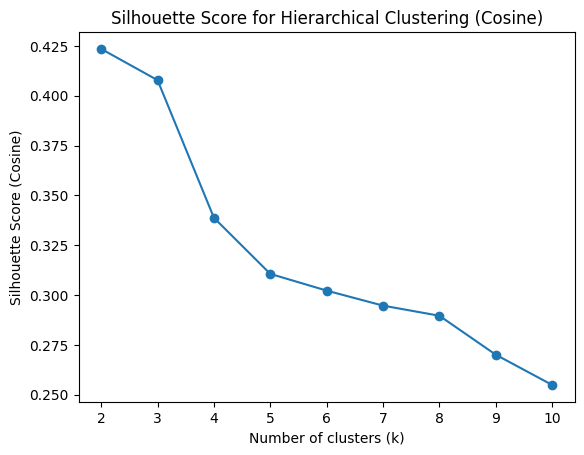

Best k for hierarchical clustering by silhouette score: 2


In [15]:
# Evaluate silhouette scores for hierarchical clustering with cosine distance
from sklearn.metrics import silhouette_score

silhouette_scores_hier = []
k_range = range(2, 11)
for k in k_range:
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(df_clustering_scaled, labels, metric='cosine')
    silhouette_scores_hier.append(score)

plt.plot(k_range, silhouette_scores_hier, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score (Cosine)')
plt.title('Silhouette Score for Hierarchical Clustering (Cosine)')
plt.savefig('hierarchical_silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_hier = k_range[np.argmax(silhouette_scores_hier)]
print(f'Best k for hierarchical clustering by silhouette score: {best_k_hier}')